# OpenAlex Works Analysis

This notebook analyzes works from the OpenAlex dataset stored in Azure Cosmos DB, focusing on attributes like author counts, institutions, publication dates, citations, and open access status.

## Import Required Libraries

In [1]:
import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Connect to Cosmos DB

Set up your connection string and database/container names.

In [2]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"  # Update with your database name
CONTAINER_NAME = "openalex-works"  # Update with your container name

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINER_NAME}")

Connected to database: aegisraw, container: openalex-works


## Query and Load Data

Query works from Cosmos DB with various attributes.

In [3]:
# Query for works with comprehensive attributes
query = """
SELECT 
    c.id,
    c.title,
    c.publication_year,
    c.publication_date,
    c.type,
    c.authors_count,
    c.authorships,
    c.cited_by_count,
    c.open_access,
    c.topics,
    c.countries_distinct_count,
    c.institutions_distinct_count
FROM c
"""

# Fetch documents
items = list(container.query_items(
    query=query,
    enable_cross_partition_query=True,
    max_item_count=10000  # Adjust based on needs
))

print(f"Fetched {len(items):,} works")

Fetched 1,176,615 works


## Extract and Prepare Data

Parse works data and extract key attributes.

In [4]:
# Extract work attributes
works_data = []

for item in items:
    # Count institutions from authorships
    institution_ids = set()
    country_codes = set()
    has_affiliation = False
    
    if item.get('authorships'):
        for authorship in item['authorships']:
            # Count institutions
            if authorship.get('institutions'):
                has_affiliation = True
                for inst in authorship['institutions']:
                    if inst.get('id'):
                        institution_ids.add(inst['id'])
            
            # Count countries
            if authorship.get('countries'):
                for country in authorship['countries']:
                    country_codes.add(country)
    
    # Extract open access info
    oa_status = None
    is_oa = False
    if item.get('open_access'):
        oa_status = item['open_access'].get('oa_status', 'unknown')
        is_oa = item['open_access'].get('is_oa', False)
    
    # Count topics
    num_topics = 0
    if item.get('topics'):
        num_topics = len(item['topics'])
    
    works_data.append({
        'id': item.get('id'),
        'title': item.get('title'),
        'publication_year': item.get('publication_year'),
        'type': item.get('type'),
        'authors_count': item.get('authors_count', 0),
        'institutions_count': len(institution_ids),
        'countries_count': len(country_codes),
        'cited_by_count': item.get('cited_by_count', 0),
        'topics_count': num_topics,
        'oa_status': oa_status,
        'is_oa': is_oa,
        'has_affiliation': has_affiliation
    })

# Create DataFrame
works_df = pd.DataFrame(works_data)

print(f"\nWorks DataFrame created with {len(works_df):,} rows")
print(f"\nColumns: {list(works_df.columns)}")
print(f"\nBasic statistics:")
print(works_df.describe())


Works DataFrame created with 1,176,615 rows

Columns: ['id', 'title', 'publication_year', 'type', 'authors_count', 'institutions_count', 'countries_count', 'cited_by_count', 'topics_count', 'oa_status', 'is_oa', 'has_affiliation']

Basic statistics:
       publication_year  authors_count  institutions_count  countries_count  \
count      1.170931e+06   1.176615e+06        1.176615e+06     1.176615e+06   
mean       2.001206e+03   2.020330e+00        1.052766e-01     8.990451e-02   
std        1.703695e+01   9.924004e+00        6.141513e-01     3.281655e-01   
min        1.198000e+03   0.000000e+00        0.000000e+00     0.000000e+00   
25%        1.997000e+03   1.000000e+00        0.000000e+00     0.000000e+00   
50%        2.006000e+03   1.000000e+00        0.000000e+00     0.000000e+00   
75%        2.011000e+03   2.000000e+00        0.000000e+00     0.000000e+00   
max        2.026000e+03   3.039000e+03        2.090000e+02     5.100000e+01   

       cited_by_count  topics_count  

## Author Count Analysis

Analyze the distribution of authors per work.

Author Count Statistics:
count    1.176615e+06
mean     2.020330e+00
std      9.924004e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.039000e+03
Name: authors_count, dtype: float64

Works with 0 authors: 6,166
Single author works: 717,638
Multi-author works: 452,811

Most authors on a single work: 3039


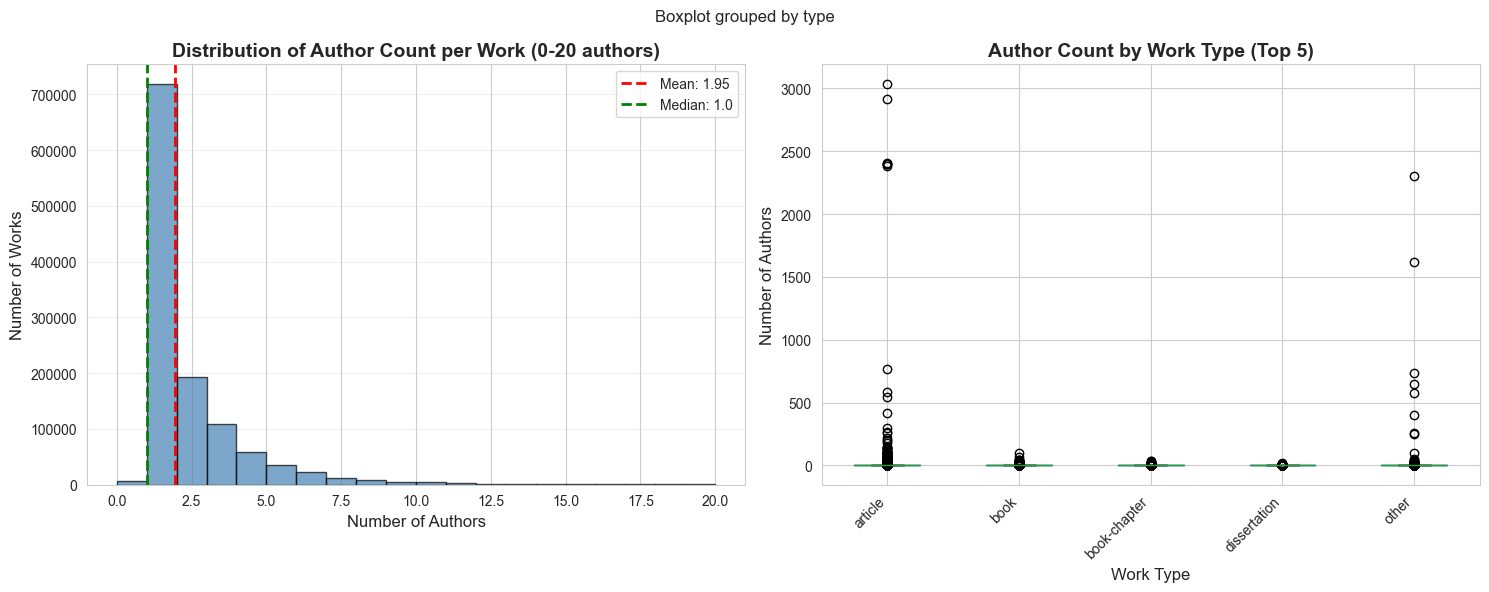

In [5]:
# Author count statistics
print("Author Count Statistics:")
print("=" * 60)
print(works_df['authors_count'].describe())
print(f"\nWorks with 0 authors: {len(works_df[works_df['authors_count'] == 0]):,}")
print(f"Single author works: {len(works_df[works_df['authors_count'] == 1]):,}")
print(f"Multi-author works: {len(works_df[works_df['authors_count'] > 1]):,}")
print(f"\nMost authors on a single work: {works_df['authors_count'].max()}")

# Visualize author count distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram (0-20 authors)
filtered_authors = works_df[works_df['authors_count'] <= 20]['authors_count']
axes[0].hist(filtered_authors, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Number of Authors', fontsize=12)
axes[0].set_ylabel('Number of Works', fontsize=12)
axes[0].set_title('Distribution of Author Count per Work (0-20 authors)', fontsize=14, fontweight='bold')
axes[0].axvline(filtered_authors.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {filtered_authors.mean():.2f}')
axes[0].axvline(filtered_authors.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {filtered_authors.median():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by work type
top_types = works_df['type'].value_counts().head(5).index
works_df[works_df['type'].isin(top_types)].boxplot(column='authors_count', by='type', ax=axes[1])
axes[1].set_xlabel('Work Type', fontsize=12)
axes[1].set_ylabel('Number of Authors', fontsize=12)
axes[1].set_title('Author Count by Work Type (Top 5)', fontsize=14, fontweight='bold')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Institution Analysis

Analyze institutional affiliations in works.

Institution Statistics:
count    1.176615e+06
mean     1.052766e-01
std      6.141513e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.090000e+02
Name: institutions_count, dtype: float64

Works with no institution: 1,076,978
Works with 1 institution: 83,330
Works with multiple institutions: 16,307
Works with affiliations: 99,637 (8.5%)


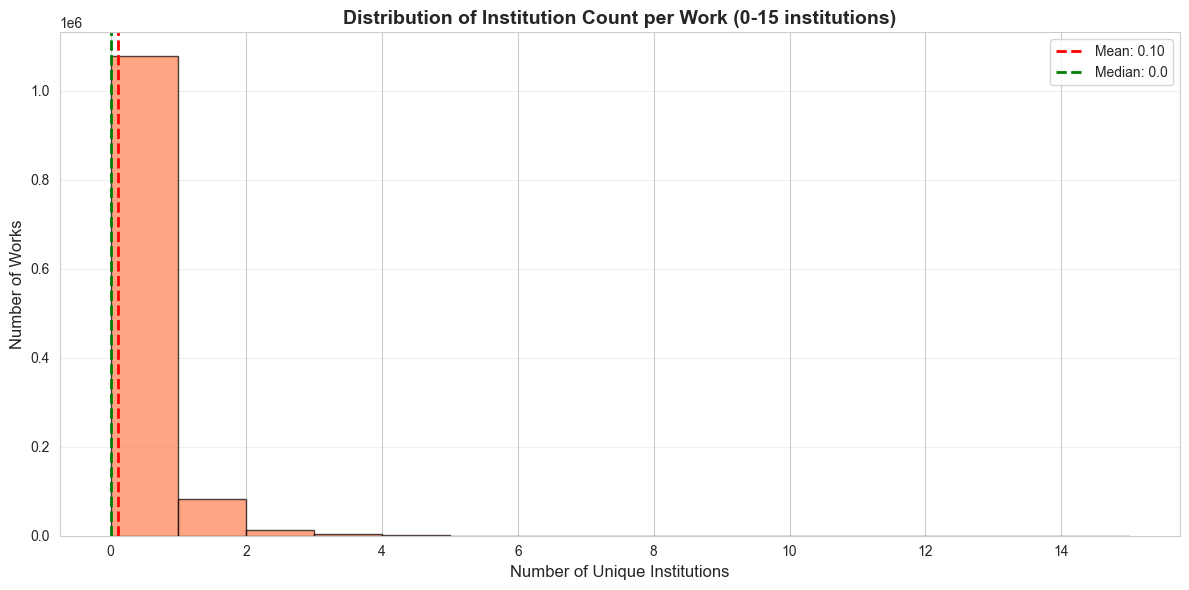

In [6]:
# Institution statistics
print("Institution Statistics:")
print("=" * 60)
print(works_df['institutions_count'].describe())
print(f"\nWorks with no institution: {len(works_df[works_df['institutions_count'] == 0]):,}")
print(f"Works with 1 institution: {len(works_df[works_df['institutions_count'] == 1]):,}")
print(f"Works with multiple institutions: {len(works_df[works_df['institutions_count'] > 1]):,}")
print(f"Works with affiliations: {works_df['has_affiliation'].sum():,} ({works_df['has_affiliation'].mean()*100:.1f}%)")

# Visualize
plt.figure(figsize=(12, 6))
filtered_inst = works_df[works_df['institutions_count'] <= 15]['institutions_count']
plt.hist(filtered_inst, bins=15, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Number of Unique Institutions', fontsize=12)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Distribution of Institution Count per Work (0-15 institutions)', fontsize=14, fontweight='bold')
plt.axvline(filtered_inst.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {filtered_inst.mean():.2f}')
plt.axvline(filtered_inst.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {filtered_inst.median():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Publication Year Analysis

Analyze temporal distribution of works.

Publication Year Statistics:
count    1.167822e+06
mean     2.001565e+03
std      1.535317e+01
min      1.900000e+03
25%      1.997000e+03
50%      2.006000e+03
75%      2.011000e+03
max      2.026000e+03
Name: publication_year, dtype: float64

Works with missing year: 5,684

Year range: 1900 - 2026


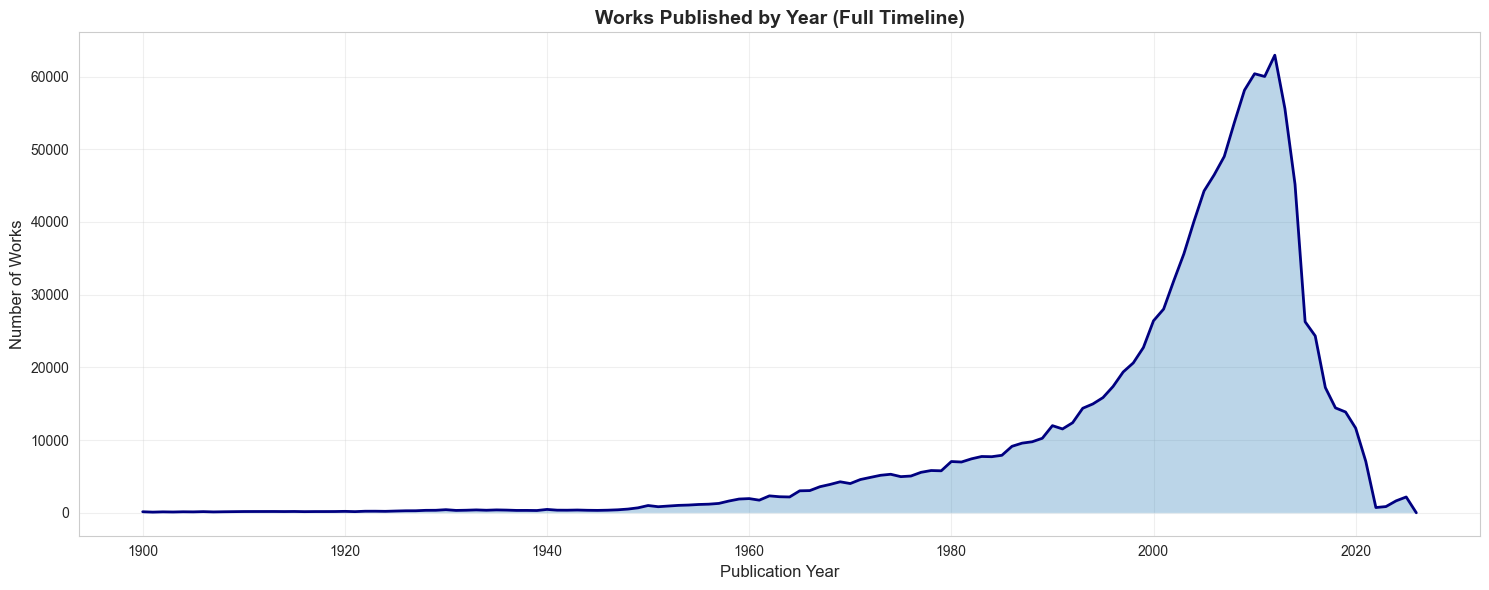

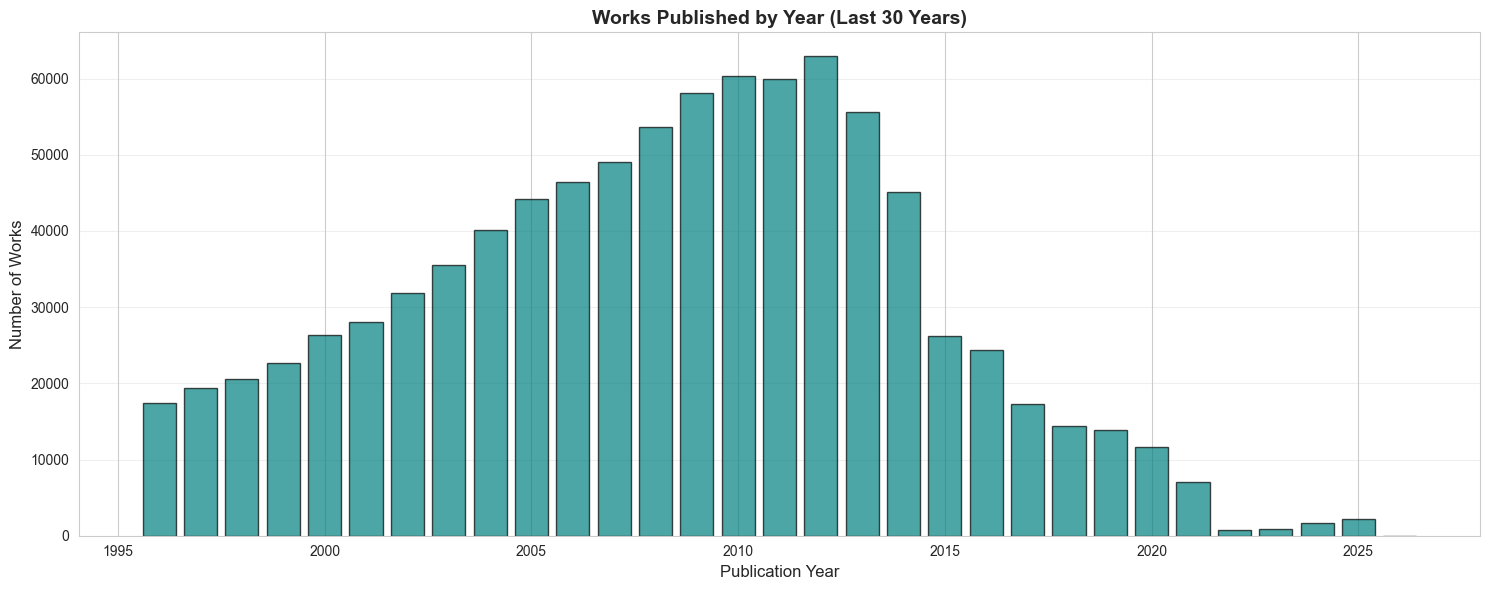

In [12]:
# Filter out invalid years
valid_years_df = works_df[works_df['publication_year'].notna() & 
                          (works_df['publication_year'] >= 1900) & 
                          (works_df['publication_year'] <= 2026)]

print("Publication Year Statistics:")
print("=" * 60)
print(valid_years_df['publication_year'].describe())
print(f"\nWorks with missing year: {works_df['publication_year'].isna().sum():,}")
print(f"\nYear range: {valid_years_df['publication_year'].min():.0f} - {valid_years_df['publication_year'].max():.0f}")

# Count by year
year_counts = valid_years_df['publication_year'].value_counts().sort_index()

# Visualize full timeline
plt.figure(figsize=(15, 6))
plt.plot(year_counts.index, year_counts.values, linewidth=2, color='navy')
plt.fill_between(year_counts.index, year_counts.values, alpha=0.3)
plt.xlabel('Publication Year', fontsize=12)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Works Published by Year (Full Timeline)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Recent years (last 30 years) - separate chart
recent_years = year_counts[year_counts.index >= (datetime.now().year - 30)]
plt.figure(figsize=(15, 6))
plt.bar(recent_years.index, recent_years.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Publication Year', fontsize=12)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Works Published by Year (Last 30 Years)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Citation Analysis

Analyze citation patterns across works.

Citation Statistics:
count    1.176615e+06
mean     1.796471e+00
std      4.413086e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.566000e+04
Name: cited_by_count, dtype: float64

Uncited works: 956,410 (81.3%)
Works with 1+ citations: 220,205
Highly cited (100+ citations): 2,542

Top 10 Most Cited Works:
                                                                                                               title  cited_by_count  publication_year     type
                                                                                        Visualizing Data using t-SNE           35660            2008.0  article
                                                                          Ecosystems and Human Well-being: Synthesis           10725            2005.0  article
                                                         SPSS for Windows Step by Step: A Simple Guide and Reference           10088            1998.0     boo

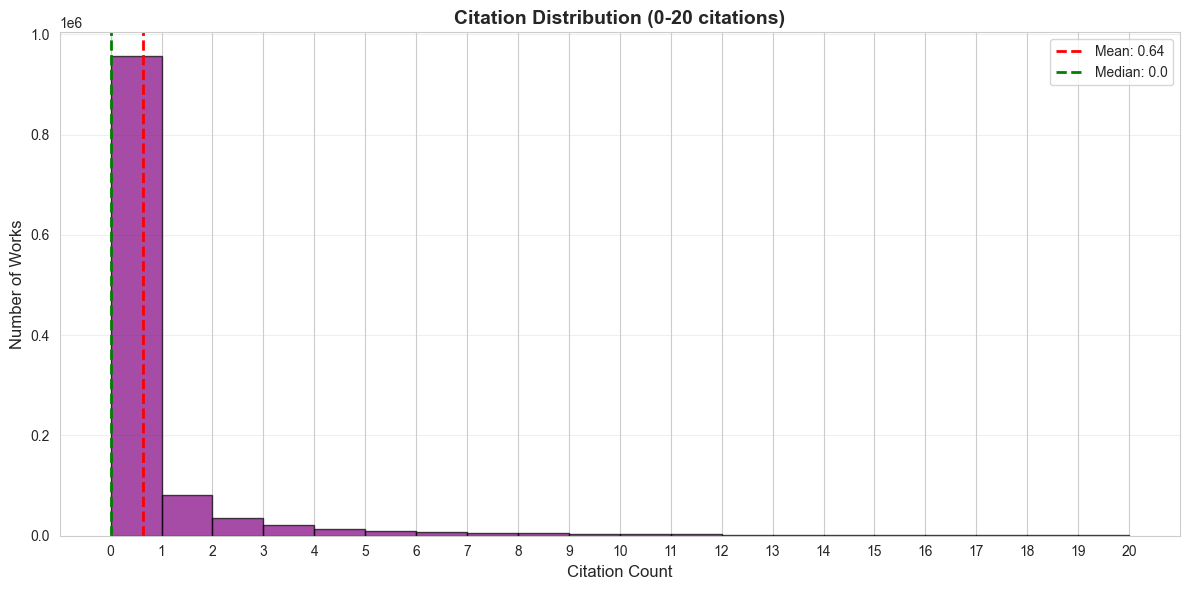

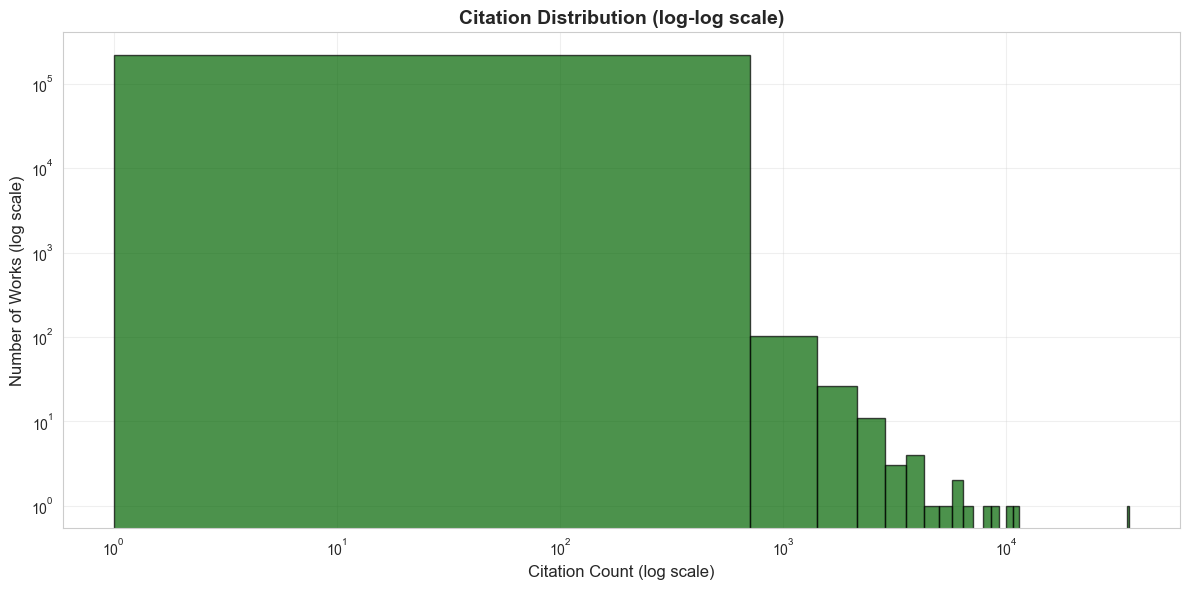

In [14]:
# Citation statistics
print("Citation Statistics:")
print("=" * 60)
print(works_df['cited_by_count'].describe())
print(f"\nUncited works: {len(works_df[works_df['cited_by_count'] == 0]):,} ({(works_df['cited_by_count'] == 0).mean()*100:.1f}%)")
print(f"Works with 1+ citations: {len(works_df[works_df['cited_by_count'] > 0]):,}")
print(f"Highly cited (100+ citations): {len(works_df[works_df['cited_by_count'] >= 100]):,}")

# Top cited works
print("\nTop 10 Most Cited Works:")
top_cited = works_df.nlargest(10, 'cited_by_count')[['title', 'cited_by_count', 'publication_year', 'type']]
print(top_cited.to_string(index=False))

# Visualize distribution for works with 0-20 citations
filtered_citations = works_df[works_df['cited_by_count'] <= 20]['cited_by_count']
plt.figure(figsize=(12, 6))
plt.hist(filtered_citations, bins=20, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Citation Count', fontsize=12)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Citation Distribution (0-20 citations)', fontsize=14, fontweight='bold')
plt.axvline(filtered_citations.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {filtered_citations.mean():.2f}')
plt.axvline(filtered_citations.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {filtered_citations.median():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(0, 21, 1))
plt.tight_layout()
plt.show()

# Log scale distribution - separate chart
plt.figure(figsize=(12, 6))
plt.hist(works_df[works_df['cited_by_count'] > 0]['cited_by_count'], 
         bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
plt.xlabel('Citation Count (log scale)', fontsize=12)
plt.ylabel('Number of Works (log scale)', fontsize=12)
plt.title('Citation Distribution (log-log scale)', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Open Access Analysis

Analyze open access status of works.

Open Access Statistics:
Open Access works: 96,437 (8.2%)
Closed works: 1,080,178 (91.8%)

OA Status Breakdown:
oa_status
closed     1080178
green        89539
gold          5040
diamond        914
hybrid         806
bronze         138
Name: count, dtype: int64


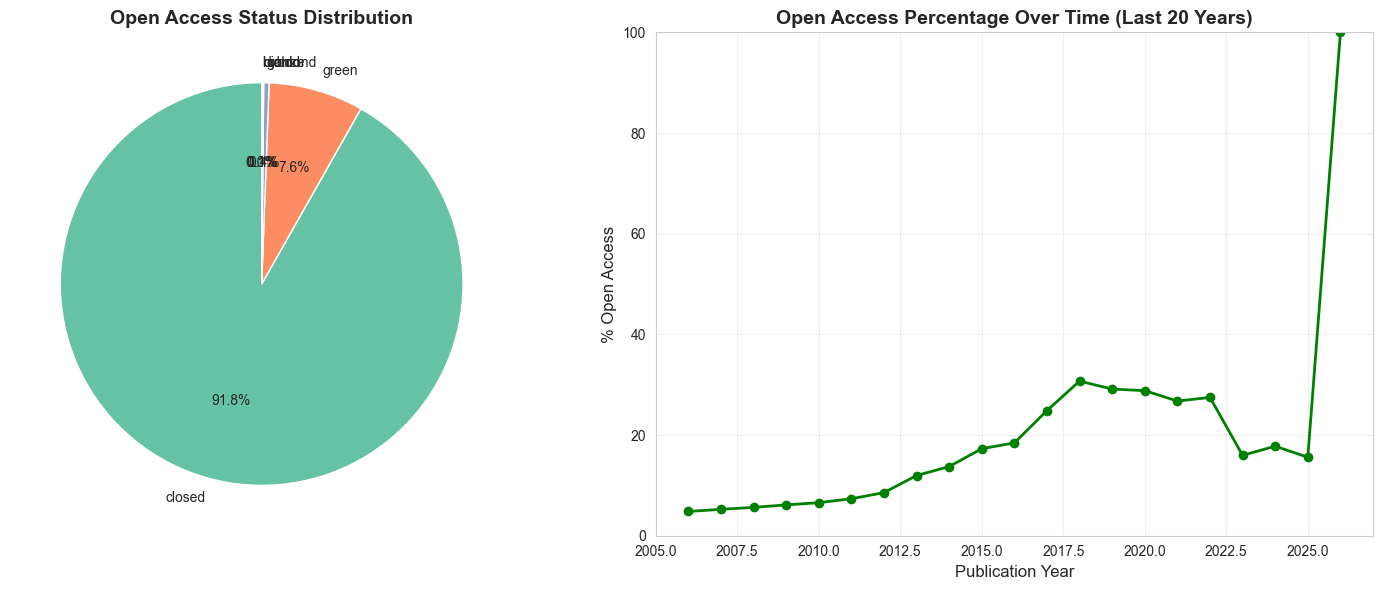

In [9]:
# Open access statistics
oa_counts = works_df['oa_status'].value_counts()
is_oa_count = works_df['is_oa'].sum()

print("Open Access Statistics:")
print("=" * 60)
print(f"Open Access works: {is_oa_count:,} ({is_oa_count/len(works_df)*100:.1f}%)")
print(f"Closed works: {len(works_df) - is_oa_count:,} ({(len(works_df) - is_oa_count)/len(works_df)*100:.1f}%)")
print("\nOA Status Breakdown:")
print(oa_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for OA status
oa_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90, 
               colors=sns.color_palette('Set2', len(oa_counts)))
axes[0].set_ylabel('')
axes[0].set_title('Open Access Status Distribution', fontsize=14, fontweight='bold')

# OA status by publication year (recent 20 years)
recent_years_oa = works_df[works_df['publication_year'] >= (datetime.now().year - 20)]
oa_by_year = recent_years_oa.groupby('publication_year')['is_oa'].agg(['sum', 'count'])
oa_by_year['percentage'] = (oa_by_year['sum'] / oa_by_year['count']) * 100

axes[1].plot(oa_by_year.index, oa_by_year['percentage'], linewidth=2, marker='o', color='green')
axes[1].set_xlabel('Publication Year', fontsize=12)
axes[1].set_ylabel('% Open Access', fontsize=12)
axes[1].set_title('Open Access Percentage Over Time (Last 20 Years)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Work Type Analysis

Analyze distribution of different work types.

Work Type Statistics:
type
article         1046190
dissertation      57476
other             31999
book              23334
book-chapter       7569
preprint           7472
review             1761
editorial           185
letter              182
paratext            180
dataset              88
erratum              63
report               48
peer-review          35
libguides            32
Name: count, dtype: int64


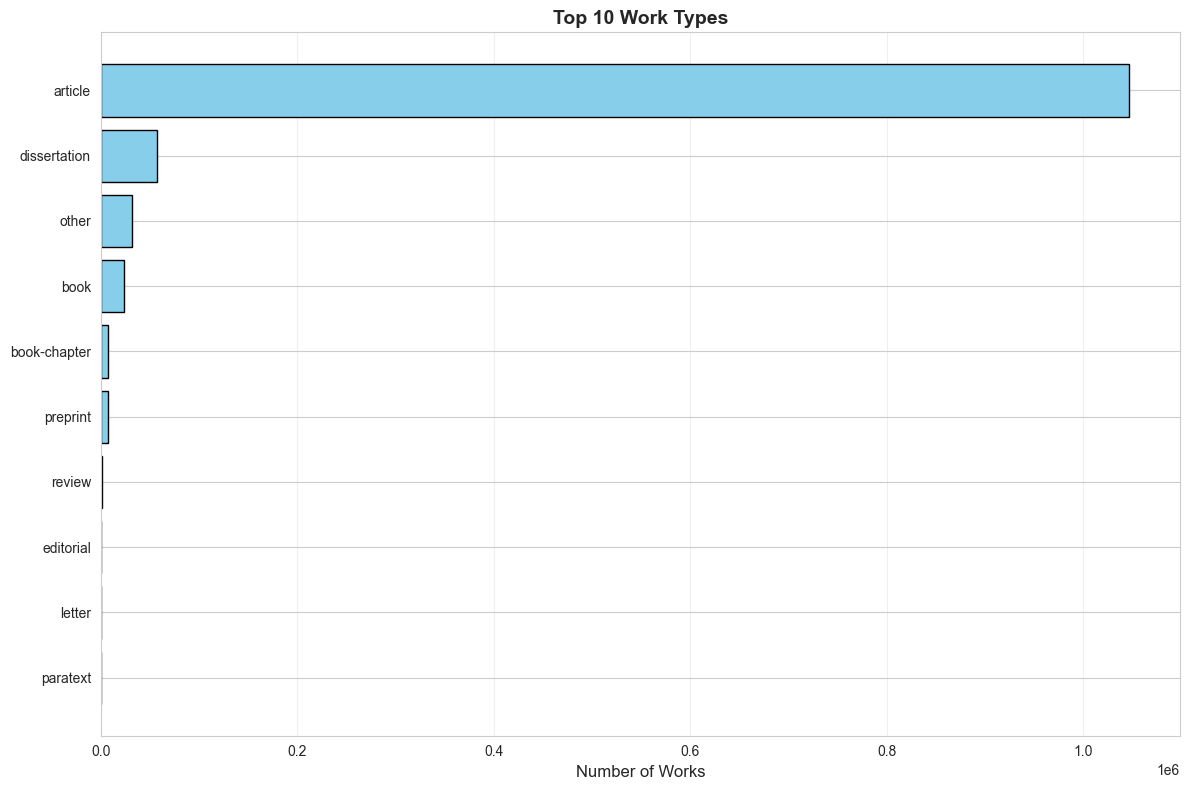

In [10]:
# Work type statistics
type_counts = works_df['type'].value_counts()

print("Work Type Statistics:")
print("=" * 60)
print(type_counts.head(15))

# Visualize top 10 types
plt.figure(figsize=(12, 8))
top_types = type_counts.head(10)
plt.barh(range(len(top_types)), top_types.values, color='skyblue', edgecolor='black')
plt.yticks(range(len(top_types)), top_types.index)
plt.xlabel('Number of Works', fontsize=12)
plt.title('Top 10 Work Types', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Correlation Analysis

Analyze relationships between different attributes.

Correlation Matrix:
                    authors_count  institutions_count  countries_count  \
authors_count            1.000000            0.446326         0.206291   
institutions_count       0.446326            1.000000         0.819873   
countries_count          0.206291            0.819873         1.000000   
cited_by_count           0.003439            0.010644         0.015731   
topics_count            -0.004200            0.103750         0.161748   
publication_year         0.017946            0.070543         0.105139   

                    cited_by_count  topics_count  publication_year  
authors_count             0.003439     -0.004200          0.017946  
institutions_count        0.010644      0.103750          0.070543  
countries_count           0.015731      0.161748          0.105139  
cited_by_count            1.000000      0.020287         -0.009772  
topics_count              0.020287      1.000000         -0.023329  
publication_year         -0.009772     -0.02332

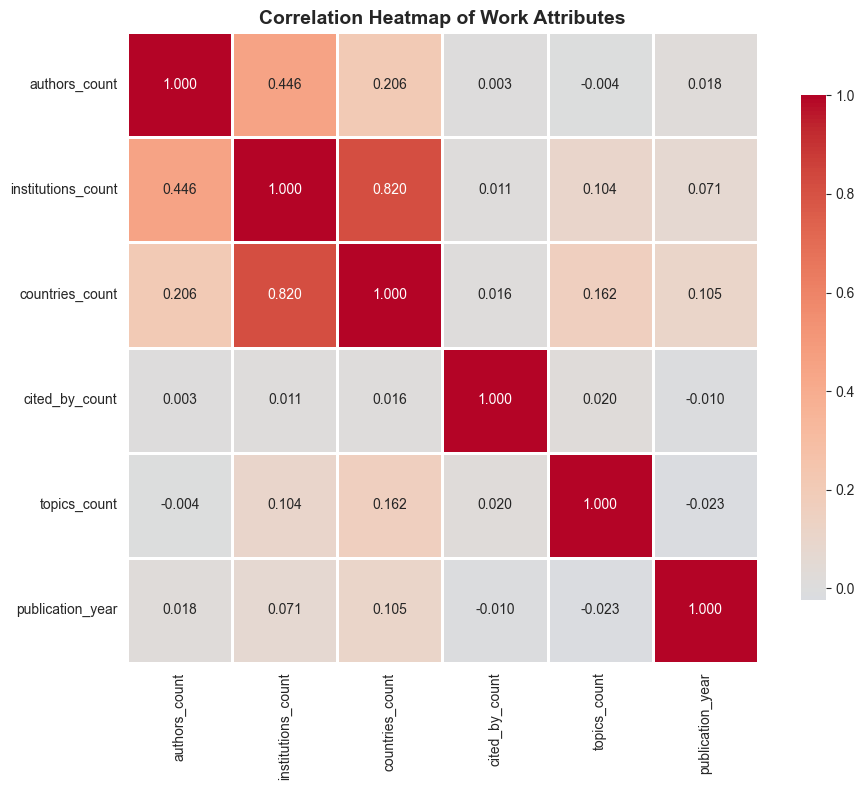

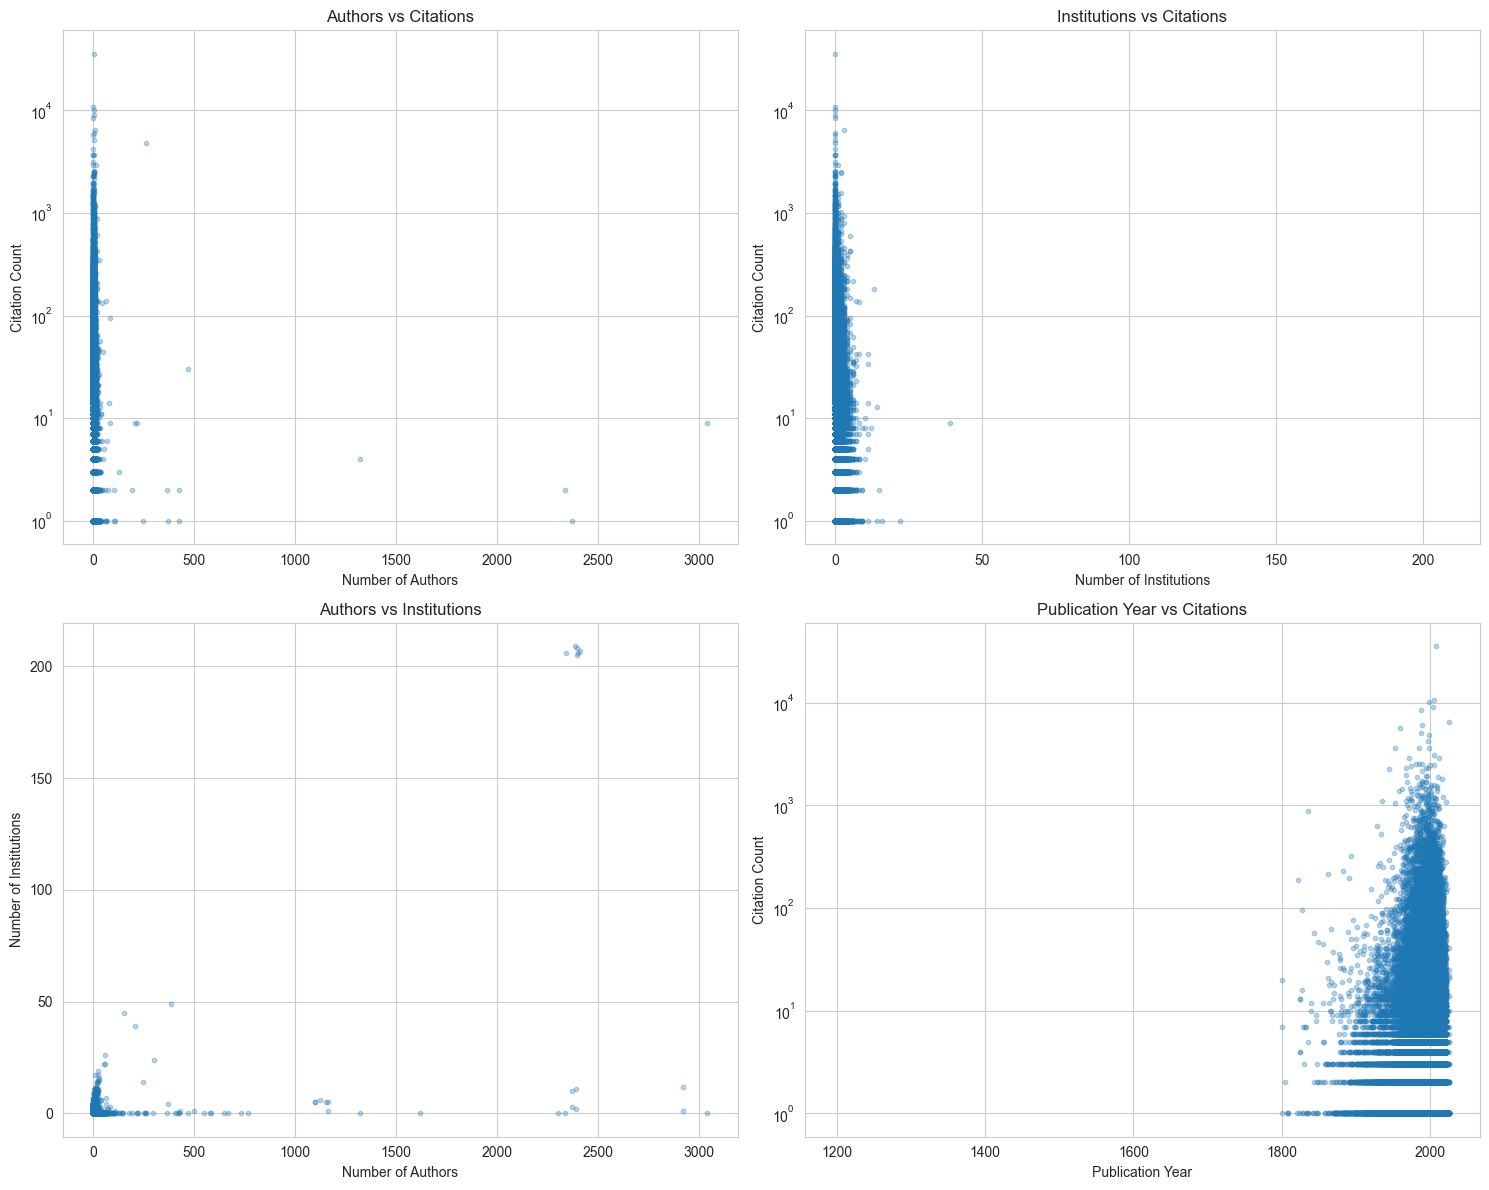

In [11]:
# Correlation matrix
numeric_cols = ['authors_count', 'institutions_count', 'countries_count', 
                'cited_by_count', 'topics_count', 'publication_year']
corr_matrix = works_df[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Work Attributes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Authors vs Citations
axes[0, 0].scatter(works_df['authors_count'], works_df['cited_by_count'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Number of Authors')
axes[0, 0].set_ylabel('Citation Count')
axes[0, 0].set_title('Authors vs Citations')
axes[0, 0].set_yscale('log')

# Institutions vs Citations
axes[0, 1].scatter(works_df['institutions_count'], works_df['cited_by_count'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Number of Institutions')
axes[0, 1].set_ylabel('Citation Count')
axes[0, 1].set_title('Institutions vs Citations')
axes[0, 1].set_yscale('log')

# Authors vs Institutions
axes[1, 0].scatter(works_df['authors_count'], works_df['institutions_count'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Number of Authors')
axes[1, 0].set_ylabel('Number of Institutions')
axes[1, 0].set_title('Authors vs Institutions')

# Year vs Citations
axes[1, 1].scatter(works_df['publication_year'], works_df['cited_by_count'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Publication Year')
axes[1, 1].set_ylabel('Citation Count')
axes[1, 1].set_title('Publication Year vs Citations')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()